In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

from analysis_functions.basic_data_inspection import DataInspector, DataTypesInspectionStrategy, SummaryStatisticsInspectionStrategy
from analysis_functions.missing_values_analysis import SimpleMissingValuesAnalysis
from analysis_functions.univariate_analysis import UnivariateAnalyzer,NumericalUnivariateAnalysis,CategoricalUnivariateAnalysis 
from analysis_functions.bivariate_analysis import BivariateAnalyzer,NumericalVsNumericalAnalysis,CategoricalVsNumericalAnalysis
from analysis_functions.multivariate_analysis import SimpleMultivariateAnalysis
from processing_functions.outlier_detection import OutlierDetector,IQROutlierDetection 




In [2]:
#Đọc dữ liệu
data_path="./autos.csv"
df=pd.read_csv(data_path,encoding='Latin-1')


## **Tiền xử lý dữ liệu**

In [3]:

data_inspector=DataInspector(DataTypesInspectionStrategy())
data_inspector.execute_inspection(df)


Data Types and Non-null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   dateCrawled          371528 non-null  object
 1   name                 371528 non-null  object
 2   seller               371528 non-null  object
 3   offerType            371528 non-null  object
 4   price                371528 non-null  int64 
 5   abtest               371528 non-null  object
 6   vehicleType          333659 non-null  object
 7   yearOfRegistration   371528 non-null  int64 
 8   gearbox              351319 non-null  object
 9   powerPS              371528 non-null  int64 
 10  model                351044 non-null  object
 11  kilometer            371528 non-null  int64 
 12  monthOfRegistration  371528 non-null  int64 
 13  fuelType             338142 non-null  object
 14  brand                371528 non-null  object
 15  n

 **Tạo cột mới và loại bỏ các cột không cần thiết cho phân tích**

In [4]:
df["car_age"] = 2016 - df["yearOfRegistration"]
df["kilometer"] = df["kilometer"].astype("object")
df_cols=["price","vehicleType","car_age","gearbox","powerPS","model","kilometer","fuelType","brand","notRepairedDamage"]
df=df[df_cols]

data_inspector.execute_inspection(df)



Data Types and Non-null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   price              371528 non-null  int64 
 1   vehicleType        333659 non-null  object
 2   car_age            371528 non-null  int64 
 3   gearbox            351319 non-null  object
 4   powerPS            371528 non-null  int64 
 5   model              351044 non-null  object
 6   kilometer          371528 non-null  object
 7   fuelType           338142 non-null  object
 8   brand              371528 non-null  object
 9   notRepairedDamage  299468 non-null  object
dtypes: int64(3), object(7)
memory usage: 28.3+ MB
None


In [5]:
data_inspector.set_strategy(SummaryStatisticsInspectionStrategy())
data_inspector.execute_inspection(df)


Summary Statistics (Numerical Features):
              price        car_age        powerPS
count  3.715280e+05  371528.000000  371528.000000
mean   1.729514e+04      11.422003     115.549477
std    3.587954e+06      92.866598     192.139578
min    0.000000e+00   -7983.000000       0.000000
25%    1.150000e+03       8.000000      70.000000
50%    2.950000e+03      13.000000     105.000000
75%    7.200000e+03      17.000000     150.000000
max    2.147484e+09    1016.000000   20000.000000

Summary Statistics (Categorical Features):
       vehicleType  gearbox   model  kilometer fuelType       brand  \
count       333659   351319  351044     371528   338142      371528   
unique           8        2     251         13        7          40   
top      limousine  manuell    golf     150000   benzin  volkswagen   
freq         95894   274214   30070     240797   223857       79640   

       notRepairedDamage  
count             299468  
unique                 2  
top                 nein  


#### Các cột có điểm bất thường cần xử lý

**price**: Có nhiều giá trị ngoài thực tế (Min = 0; Max = 2,147,484,000). Đây là giá ảo do người bán nhập. Cần lọc giữ khoảng hợp lý [1000 – 50,000].

**car_age**: Có các giá trị âm do năm đăng kí xe không đúng so với thời gian bán xe (2016)

**powerPS**: Xuất hiện nhiều outlier (Min = 0; Max = 20,000). Xe phổ thông thường nằm trong khoảng 50 – 300 PS. Những giá trị ngoài khoảng này là bất hợp lý → cần lọc.



In [6]:
df[["price","powerPS"]].describe(percentiles=[0.05, 0.95])

,price,powerPS
count,3.715280e+05,371528.000000
mean,1.729514e+04,115.549477
std,3.587954e+06,192.139578
min,0.000000e+00,0.000000
5%,2.000000e+02,0.000000
50%,2.950000e+03,105.000000
95%,1.979000e+04,231.000000
max,2.147484e+09,20000.000000


**Thực hiện loại bỏ outlier bằng cách lọc dữ liệu theo các điệu kiện phù hợp với thực tế**

In [7]:
df = df[
    (df["car_age"].between(1, 30)) &
    (df["price"].between(1000, 50000))&
    (df["powerPS"]>50)
]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 245298 entries, 1 to 371527
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   price              245298 non-null  int64 
 1   vehicleType        242795 non-null  object
 2   car_age            245298 non-null  int64 
 3   gearbox            242222 non-null  object
 4   powerPS            245298 non-null  int64 
 5   model              238499 non-null  object
 6   kilometer          245298 non-null  object
 7   fuelType           237424 non-null  object
 8   brand              245298 non-null  object
 9   notRepairedDamage  218566 non-null  object
dtypes: int64(3), object(7)
memory usage: 20.6+ MB


2025-10-10 09:40:40,172 - INFO - Executing outlier detection strategy.
2025-10-10 09:40:40,173 - INFO - Detecting outliers using the IQR method.
2025-10-10 09:40:40,183 - INFO - Outliers detected using the IQR method.
2025-10-10 09:40:40,184 - INFO - Visualizing outliers for features: ['powerPS']


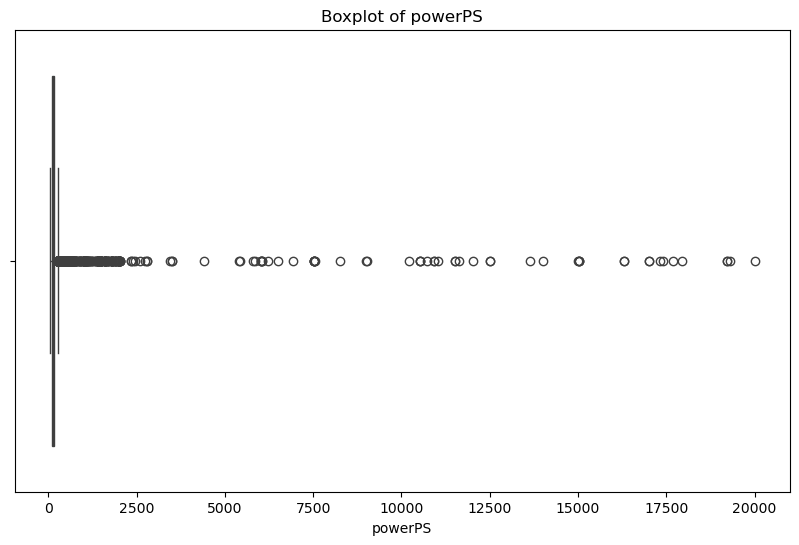

2025-10-10 09:40:40,742 - INFO - Outlier visualization completed.


In [8]:
outlier_detector=OutlierDetector(IQROutlierDetection())
outlier_powerPS=outlier_detector.detect_outliers(df,"powerPS")
outlier_detector.visualize_outliers( df,features=["powerPS"])

2025-10-10 09:40:40,755 - INFO - Executing outlier detection strategy.
2025-10-10 09:40:40,756 - INFO - Detecting outliers using the IQR method.
2025-10-10 09:40:40,770 - INFO - Outliers detected using the IQR method.
2025-10-10 09:40:40,771 - INFO - Removing outliers from the dataset.
2025-10-10 09:40:40,794 - INFO - Outlier handling completed.
2025-10-10 09:40:40,802 - INFO - Visualizing outliers for features: ['powerPS']


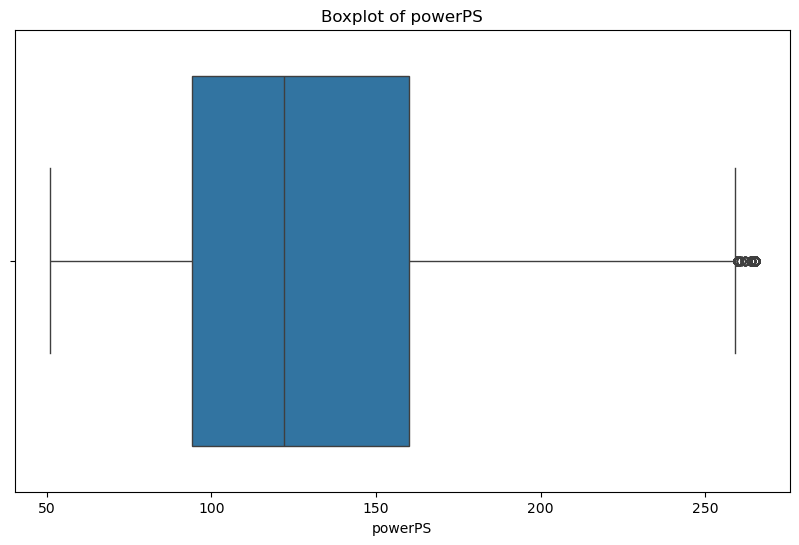

2025-10-10 09:40:41,169 - INFO - Outlier visualization completed.


In [9]:
df=outlier_detector.handle_outliers(df,column_name="powerPS",method="remove")
outlier_detector.visualize_outliers(df,features=["powerPS"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 236338 entries, 1 to 371526
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   price              236338 non-null  int64 
 1   vehicleType        233926 non-null  object
 2   car_age            236338 non-null  int64 
 3   gearbox            233345 non-null  object
 4   powerPS            236338 non-null  int64 
 5   model              230095 non-null  object
 6   kilometer          236338 non-null  object
 7   fuelType           228735 non-null  object
 8   brand              236338 non-null  object
 9   notRepairedDamage  210405 non-null  object
dtypes: int64(3), object(7)
memory usage: 19.8+ MB


**Phân tích,xử lý missing values kết hợp chuyển đổi ngôn ngữ Đức -> Anh**


Missing Values Count by Column:
vehicleType           2412
gearbox               2993
model                 6243
fuelType              7603
notRepairedDamage    25933
dtype: int64

Visualizing Missing Values...


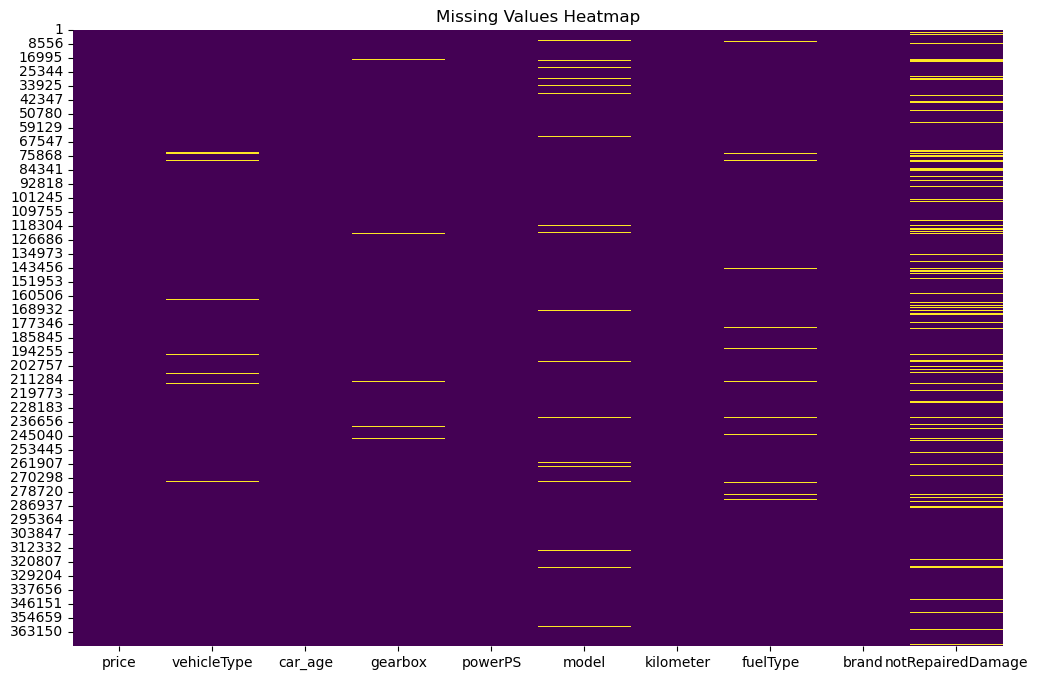

In [11]:

missing_value_analyzer = SimpleMissingValuesAnalysis()
missing_value_analyzer.analyze(df)

**=>Tất cả các cột có missing values đều là category, thực hiện kiểm tra các giá trị trong từng cột để chọn phương thức xử lý phù hợp.**

In [12]:
df["vehicleType"].unique()


array(['coupe', 'suv', 'kleinwagen', 'cabrio', 'bus', 'limousine',
       'kombi', 'andere', nan], dtype=object)

**->Có nhiều giá trị , chuyển đổi về thành ngôn ngữ tiếng anh tương ứng và fill null bằng Other**

In [13]:


df["vehicleType"] = df["vehicleType"].str.lower()
# Mapping tiếng Đức → tiếng Anh
mapping = {
    "coupe": "coupe",
    "suv": "suv",
    "kleinwagen": "small car",
    "limousine": "sedan",
    "cabrio": "convertible",
    "bus": "bus/van",
    "kombi": "station wagon",
    "andere": "other",
}

# Áp dụng mapping
df["vehicleType"] = df["vehicleType"].map(mapping)
df["vehicleType"] = df["vehicleType"].fillna("other")
df["vehicleType"].unique()

array(['coupe', 'suv', 'small car', 'convertible', 'bus/van', 'sedan',
       'station wagon', 'other'], dtype=object)

In [14]:
df["gearbox"].unique()


array(['manuell', 'automatik', nan], dtype=object)

In [15]:


# Chuyển về chữ thường để tránh mismatch
df["gearbox"] = df["gearbox"].str.lower()

# Mapping tiếng Đức -> tiếng Anh
gearbox_mapping = {
    "manuell": "manual",
    "automatik": "automatic"
}


df["gearbox"] = df["gearbox"].map(gearbox_mapping).fillna("unknown")


print(df["gearbox"].unique())

['manual' 'automatic' 'unknown']


In [16]:
df["model"].unique()


array([nan, 'grand', 'golf', 'fabia', '2_reihe', 'c_max', '3_reihe',
       'passat', 'navara', 'twingo', 'a_klasse', 'scirocco', '5er',
       'civic', 'e_klasse', '3er', 'kadett', 'andere', 'one', 'fortwo',
       '1er', 'b_klasse', 'a8', 'jetta', 'c_klasse', 'micra', 'vito',
       'sprinter', 'forester', 'xc_reihe', 'fiesta', 'scenic', 'a1',
       'transporter', 'focus', 'a4', 'tt', 'astra', 'a6', 'jazz', 'polo',
       'slk', 'combo', '80', '147', 'glk', 'z_reihe', 'sorento', 'ibiza',
       'eos', 'touran', 'getz', 'insignia', 'ka', 'megane', 'a3',
       'cordoba', 'clio', 'impreza', 'lupo', 'berlingo', '7er',
       'm_klasse', 'tiguan', 'mustang', '6_reihe', 'c4', 'panda', 'up',
       'i_reihe', 'ceed', '5_reihe', 'yeti', 'octavia', 'zafira', 'mii',
       'rx_reihe', 'corsa', 'punto', 'fox', 'vectra', 'matiz', 'beetle',
       'rio', 'touareg', 'logan', 'spider', 'cuore', 's_max', 'modus',
       'a2', 'x_reihe', 'a5', 'galaxy', 'c3', 'viano', 'mondeo', 'sharan',
       'av

**-> có quá nhiêu giá trị, fill bằng unknown**

In [17]:
df["model"]=df["model"].fillna("unknown")

In [18]:
df["fuelType"].unique()


array(['diesel', 'benzin', nan, 'lpg', 'andere', 'hybrid', 'cng',
       'elektro'], dtype=object)

**->Có andere , chuyển đổi sang tiếng anh và fill bằng Other**

In [19]:
df["fuelType"] = df["fuelType"].fillna("unknown").str.lower()

fuel_mapping = {
    "benzin": "petrol",
    "diesel": "diesel",
    "lpg": "LPG",
    "cng": "CNG",
    "hybrid": "hybrid",
    "elektro": "electric",
    "andere": "other"
}

df["fuelType"] = df["fuelType"].map(fuel_mapping).fillna("other")
print(df["fuelType"].unique())

['diesel' 'petrol' 'other' 'LPG' 'hybrid' 'CNG' 'electric']


In [20]:
df["notRepairedDamage"].unique()

array(['ja', nan, 'nein'], dtype=object)

In [21]:
df["notRepairedDamage"] = df["notRepairedDamage"].fillna("unknown").str.lower()

damage_mapping = {
    "ja": "yes",
    "nein": "no"
}

df["notRepairedDamage"] = df["notRepairedDamage"].map(damage_mapping)
df["notRepairedDamage"] = df["notRepairedDamage"].fillna("unknown")
print(df["notRepairedDamage"].unique())

['yes' 'unknown' 'no']


<class 'pandas.core.frame.DataFrame'>
Index: 236338 entries, 1 to 371526
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   price              236338 non-null  int64 
 1   vehicleType        236338 non-null  object
 2   car_age            236338 non-null  int64 
 3   gearbox            236338 non-null  object
 4   powerPS            236338 non-null  int64 
 5   model              236338 non-null  object
 6   kilometer          236338 non-null  object
 7   fuelType           236338 non-null  object
 8   brand              236338 non-null  object
 9   notRepairedDamage  236338 non-null  object
dtypes: int64(3), object(7)
memory usage: 19.8+ MB

Missing Values Count by Column:
Series([], dtype: int64)

Visualizing Missing Values...


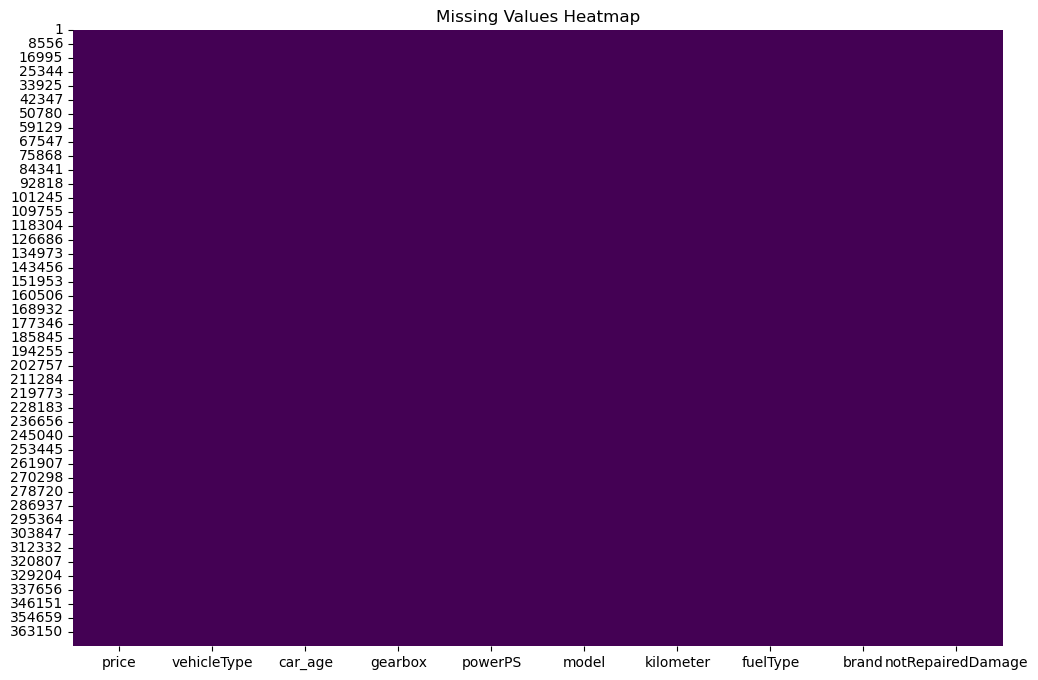

In [22]:
df.info()
df_cleaned = df.copy()
missing_value_analyzer.analyze(df_cleaned)


### **Phân tích đơn biến**

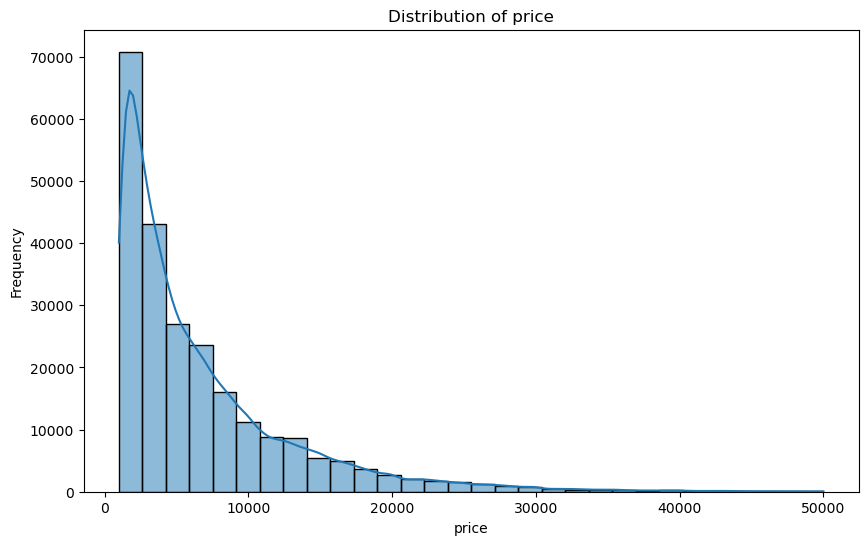

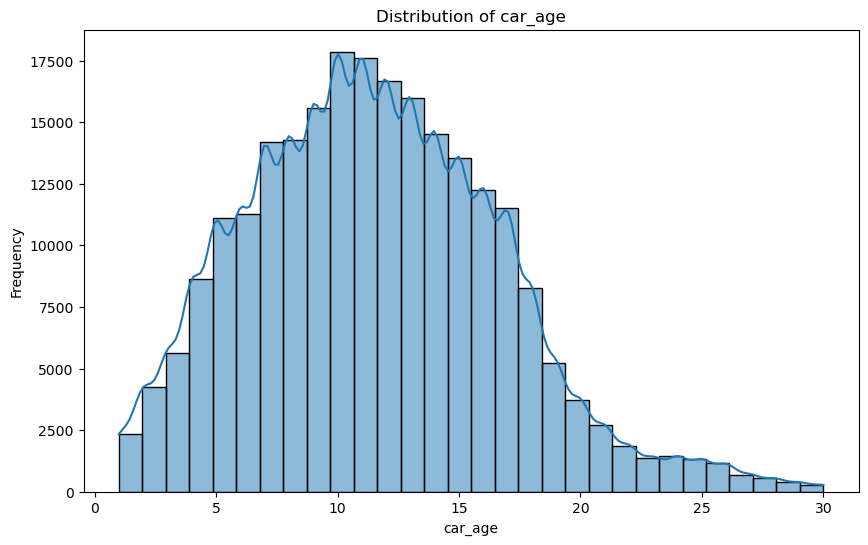

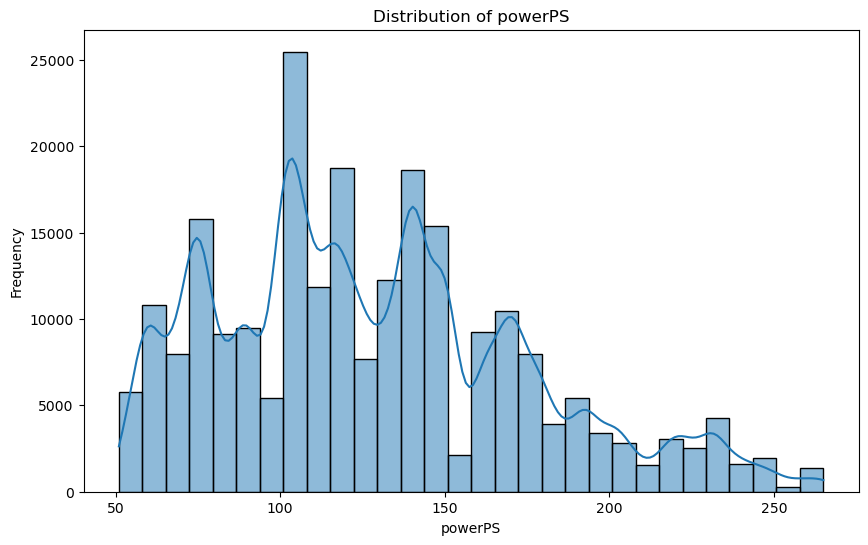

In [23]:

numeric_columns=["price","car_age","powerPS"]

univariate_analyzer=UnivariateAnalyzer(NumericalUnivariateAnalysis())

for column_name in numeric_columns:
    univariate_analyzer.execute_analysis(df,column_name)




c:\Users\quang\OneDrive\Desktop\DuAnCuoiKhoa\analysis_functions\univariate_analysis.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s_plot, order=order, palette="muted")


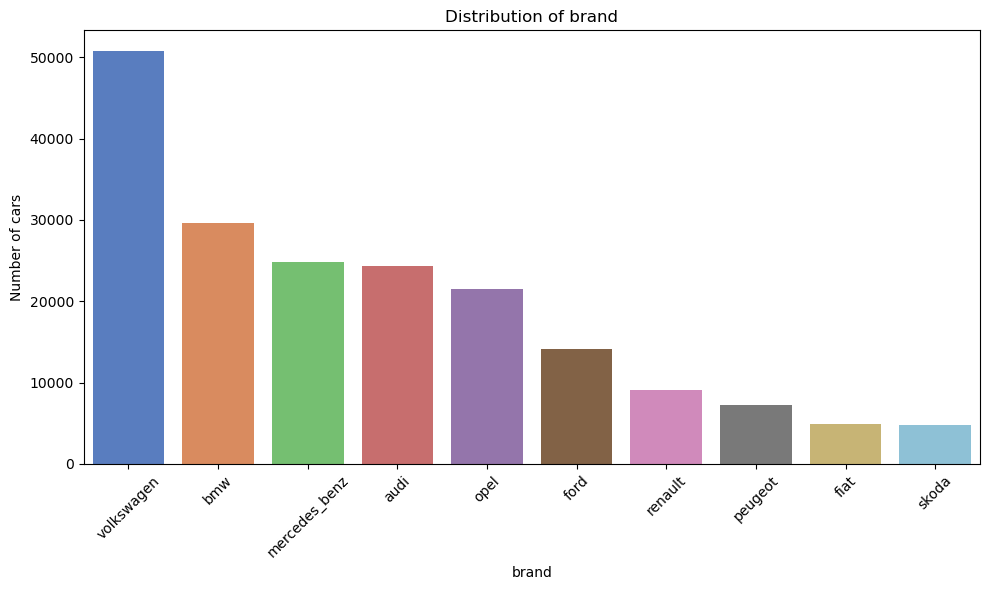

c:\Users\quang\OneDrive\Desktop\DuAnCuoiKhoa\analysis_functions\univariate_analysis.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s_plot, order=order, palette="muted")


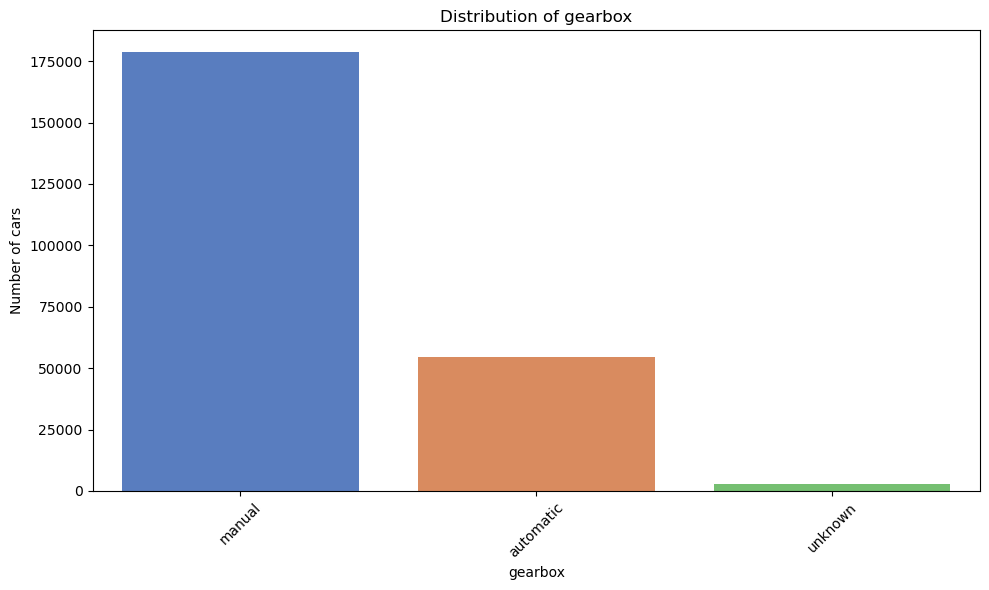

c:\Users\quang\OneDrive\Desktop\DuAnCuoiKhoa\analysis_functions\univariate_analysis.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s_plot, order=order, palette="muted")


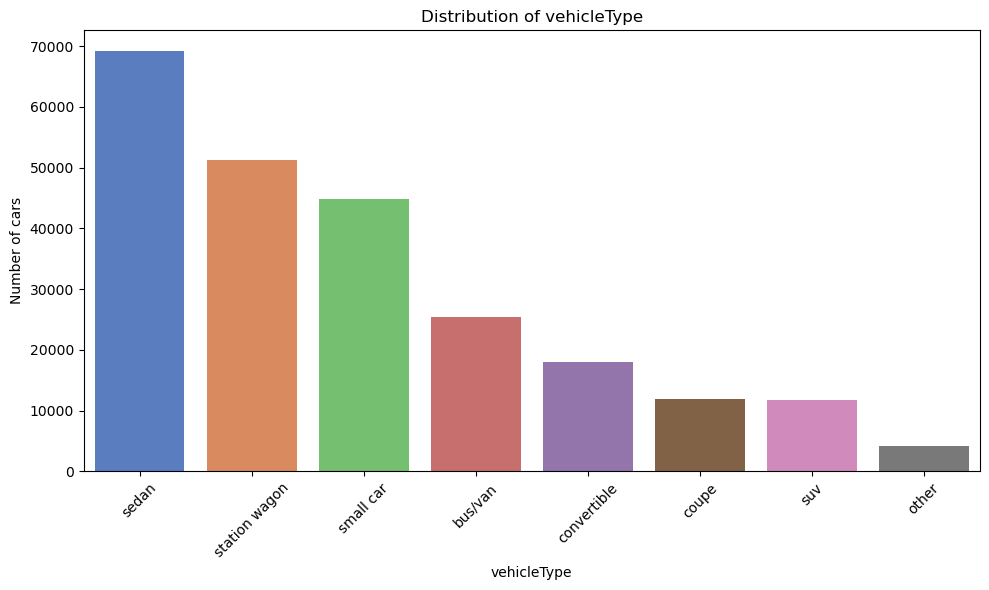

c:\Users\quang\OneDrive\Desktop\DuAnCuoiKhoa\analysis_functions\univariate_analysis.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s_plot, order=order, palette="muted")


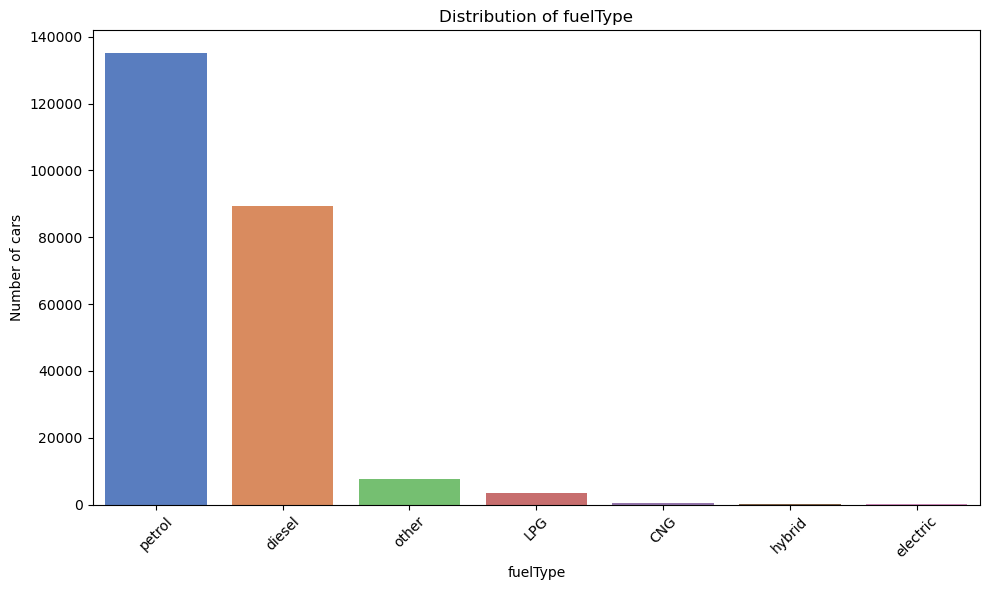

c:\Users\quang\OneDrive\Desktop\DuAnCuoiKhoa\analysis_functions\univariate_analysis.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s_plot, order=order, palette="muted")


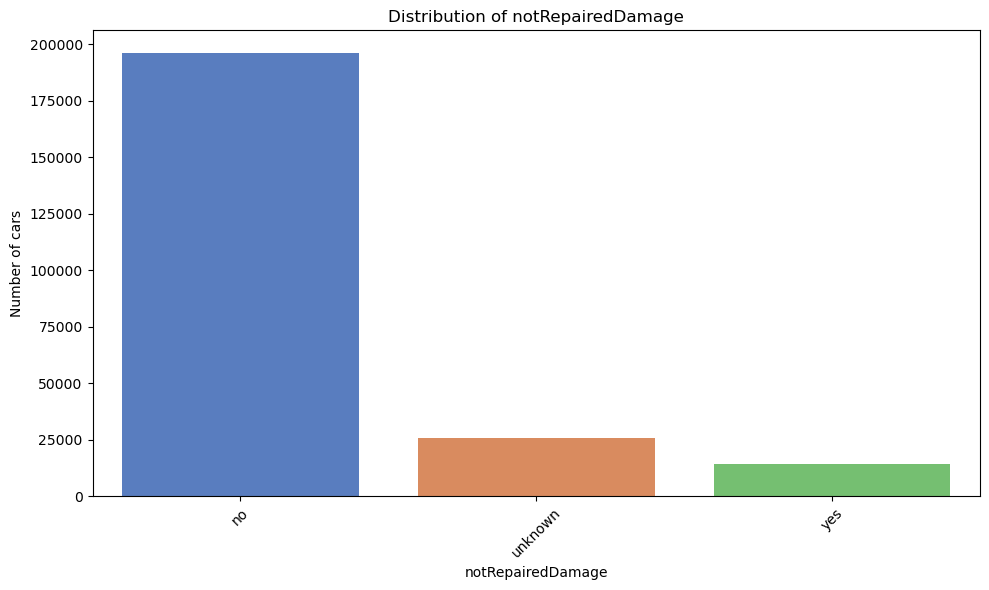

2025-10-10 09:40:54,046 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
c:\Users\quang\OneDrive\Desktop\DuAnCuoiKhoa\analysis_functions\univariate_analysis.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=s_plot, order=order, palette="muted")
2025-10-10 09:40:54,182 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


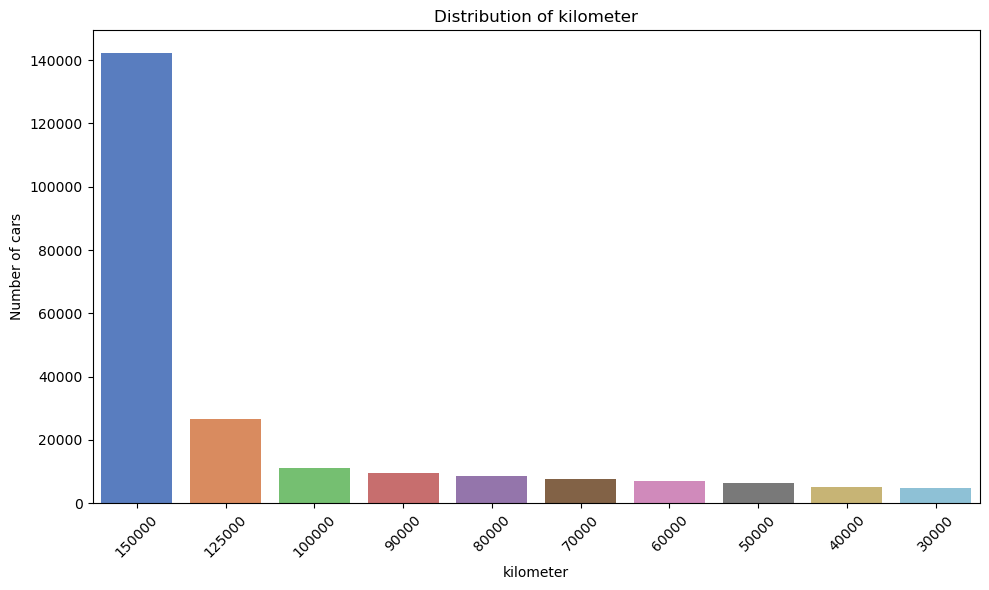

In [24]:
univariate_analyzer.set_strategy(CategoricalUnivariateAnalysis())
categorical_columns=["brand","gearbox","vehicleType","fuelType","notRepairedDamage","kilometer"]

for column_name in categorical_columns:
    univariate_analyzer.execute_analysis(df_cleaned,column_name)



### **Phân tích hai biến**

**Tương quan price và các trường categorical**


In [25]:

import matplotlib.pyplot as plt
import seaborn as sns

def plot_mean_median_by_category(df, col, top_n=None):
    # Tính mean và median theo nhóm
    stats = df.groupby(col)["price"].agg(["mean", "median"]).sort_values("median", ascending=False)

    if top_n:  # chỉ lấy top N nhóm
        stats = stats.head(top_n)

    # Vẽ barplot mean và median song song
    plt.figure(figsize=(10,6))
    stats[["mean", "median"]].plot(kind="bar", width=0.7)
    plt.title(f"Mean vs Median Price by {col}")
    plt.ylabel("Price")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.legend(["Mean", "Median"])
    plt.tight_layout()
    plt.show()


<Figure size 1000x600 with 0 Axes>

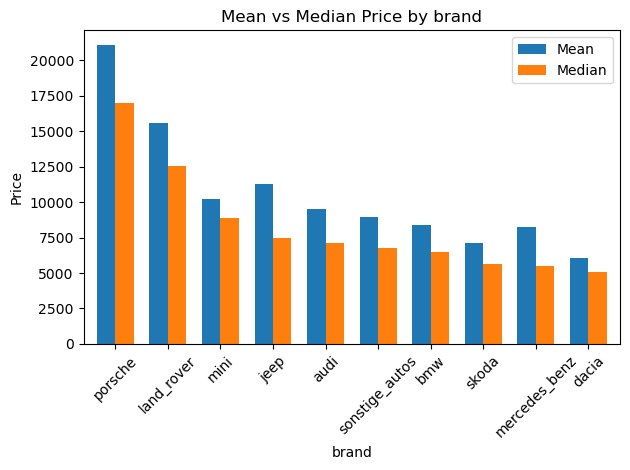

<Figure size 1000x600 with 0 Axes>

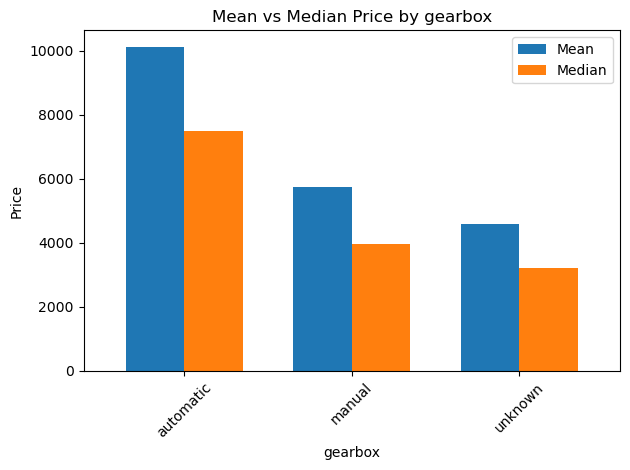

<Figure size 1000x600 with 0 Axes>

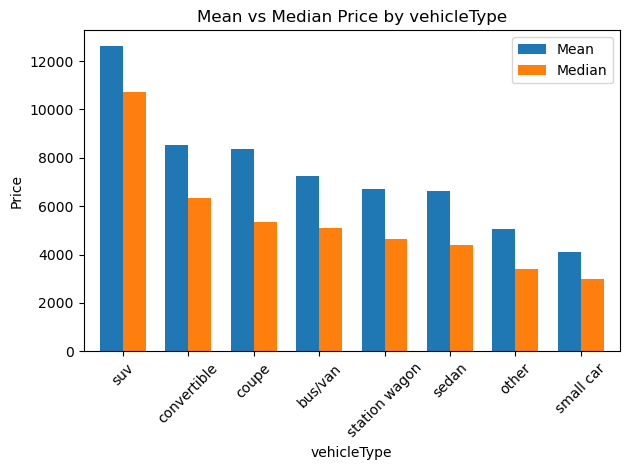

<Figure size 1000x600 with 0 Axes>

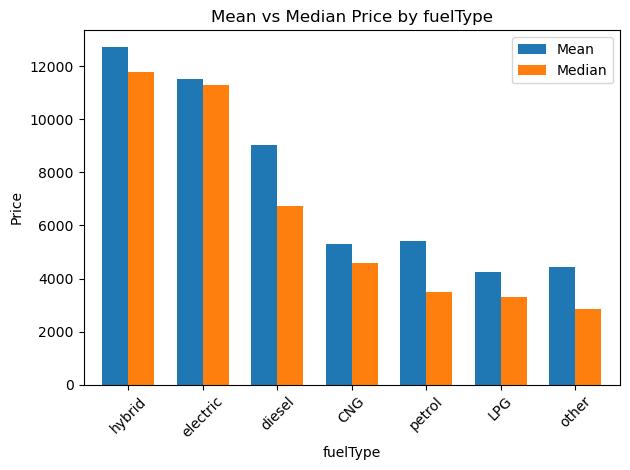

<Figure size 1000x600 with 0 Axes>

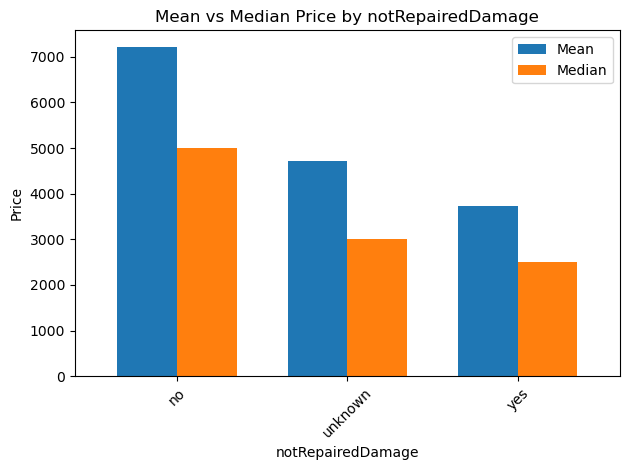

<Figure size 1000x600 with 0 Axes>

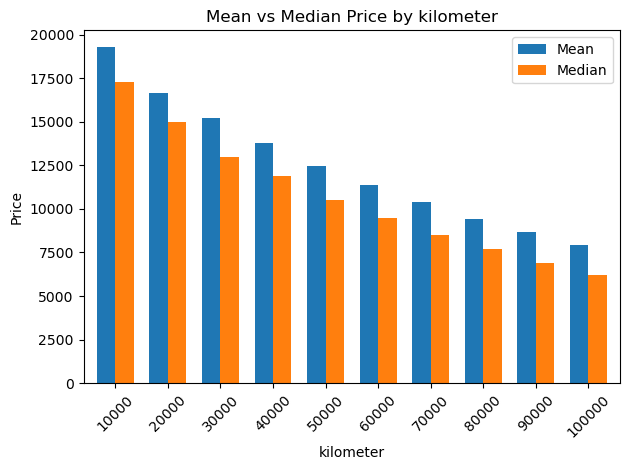

In [26]:
for col in categorical_columns:
    plot_mean_median_by_category(df, col, top_n=10)

**Tương quan giữa price và các trường nummerical**
 

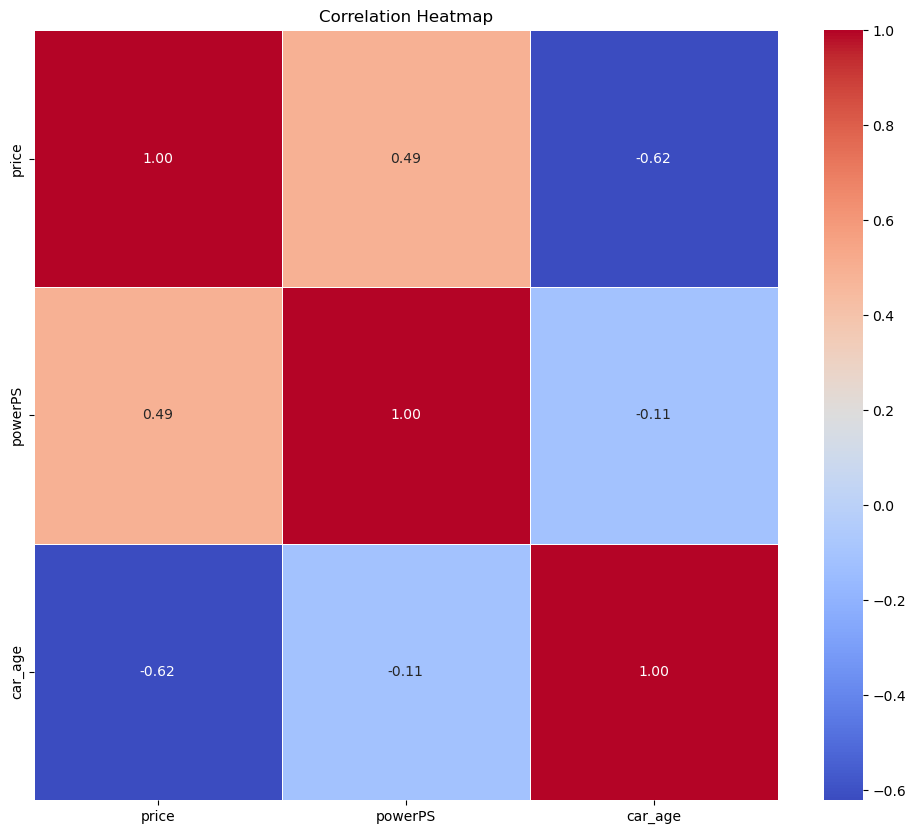

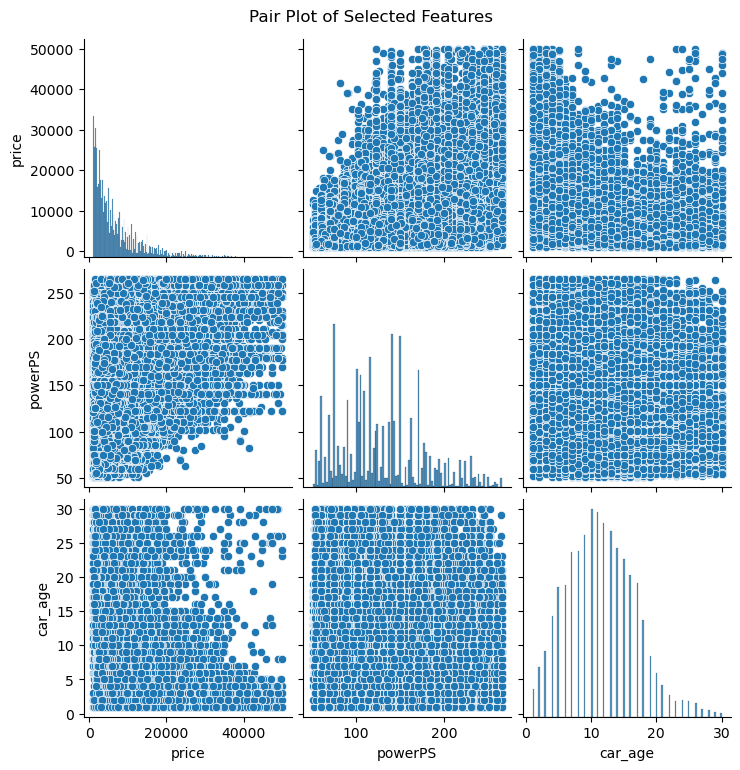

In [27]:

multivariate_analyzer = SimpleMultivariateAnalysis()

selected_features = df_cleaned[ ["price","powerPS","car_age"]]
 
multivariate_analyzer.analyze(selected_features)

In [28]:
db_params ={
    "host":"localhost",
    "port":"3306",
    "database":"DB_car_price_analysis",
    "user":"root",
    "password":"zxczxc312"
}

engine = create_engine(f"mysql+pymysql://{db_params["user"]}:{db_params["password"]}@{db_params["host"]}:{db_params["port"]}/{db_params["database"]}")

In [29]:
df_cleaned.to_sql("autos_clean",con=engine,if_exists="replace",index="False")

236338